In [1]:
# Install library yang diperlukan
!pip install optuna xgboost scikit-learn pandas numpy matplotlib seaborn --quiet


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================================
# Import semua library
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json

import optuna
from optuna.samplers import TPESampler

import xgboost as xgb
from xgboost import XGBRegressor

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#from google.colab import files

# Konfigurasi
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('✅ Library berhasil diimport.')
print(f'   XGBoost : {xgb.__version__}')
print(f'   Optuna  : {optuna.__version__}')

C:\gitA\Semester 8\Prediksi Harga Saham BBCA\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Library berhasil diimport.
   XGBoost : 3.2.0
   Optuna  : 4.9.0


In [3]:
# ============================================================
# Upload file CSV dari perangkat lokal
# ============================================================
filename = "bbca_data.csv"
df = pd.read_csv(filename)

In [4]:
# ============================================================
# Baca CSV, set Date sebagai index, urutkan ascending
# ============================================================
df = pd.read_csv(filename, parse_dates=['Date'], index_col='Date')
df = df.sort_index(ascending=True)

required_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
missing_cols  = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f'Kolom berikut tidak ditemukan: {missing_cols}')

print('✅ Dataset berhasil dimuat.')
print(f'   Baris   : {len(df):,}')
print(f'   Periode : {df.index.min().date()} s.d. {df.index.max().date()}')
print(f'   Kolom   : {list(df.columns)}')
df.head()

✅ Dataset berhasil dimuat.
   Baris   : 2,466
   Periode : 2016-01-04 s.d. 2025-12-30
   Kolom   : ['Close', 'High', 'Low', 'Open', 'Volume']


,Close,High,Low,Open,Volume
Date,,,,,
2016-01-04,2180.4744,2213.4494,2168.1087,2172.2306,77479500
2016-01-05,2205.2056,2234.0587,2176.3524,2176.3524,96609000
2016-01-06,2176.3528,2225.8153,2176.3528,2196.9622,105370000
2016-01-07,2143.3774,2168.1087,2143.3774,2159.8650,146746500
2016-01-08,2143.3774,2159.8650,2135.1337,2135.1337,125820000


In [5]:
# ============================================================
# Statistik deskriptif
# ============================================================
print('=== Statistik Deskriptif ===')
display(df.describe())

=== Statistik Deskriptif ===


,Close,High,Low,Open,Volume
count,2466.0000,2466.0000,2466.0000,2466.0000,2466.0000
mean,5869.1989,5922.3214,5817.6769,5870.4435,86984114.3958
std,2318.9172,2339.1170,2300.9204,2319.4919,61795162.6052
min,2102.1587,2131.6763,2098.4341,2102.5891,0.0000
25%,3936.1587,3962.3615,3902.1810,3940.4147,55207950.0000
50%,5622.1274,5686.4418,5557.8507,5635.1468,75014500.0000
75%,8074.2190,8173.2550,8017.2971,8094.3760,103083375.0000
max,10500.9971,10500.9971,10333.1719,10453.0463,1062861500.0000


In [6]:
# ============================================================
# Cek missing value
# ============================================================
print('=== Missing Value per Kolom ===')
print(df.isnull().sum())
df.info()

=== Missing Value per Kolom ===
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2466 entries, 2016-01-04 to 2025-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2466 non-null   float64
 1   High    2466 non-null   float64
 2   Low     2466 non-null   float64
 3   Open    2466 non-null   float64
 4   Volume  2466 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 115.6 KB


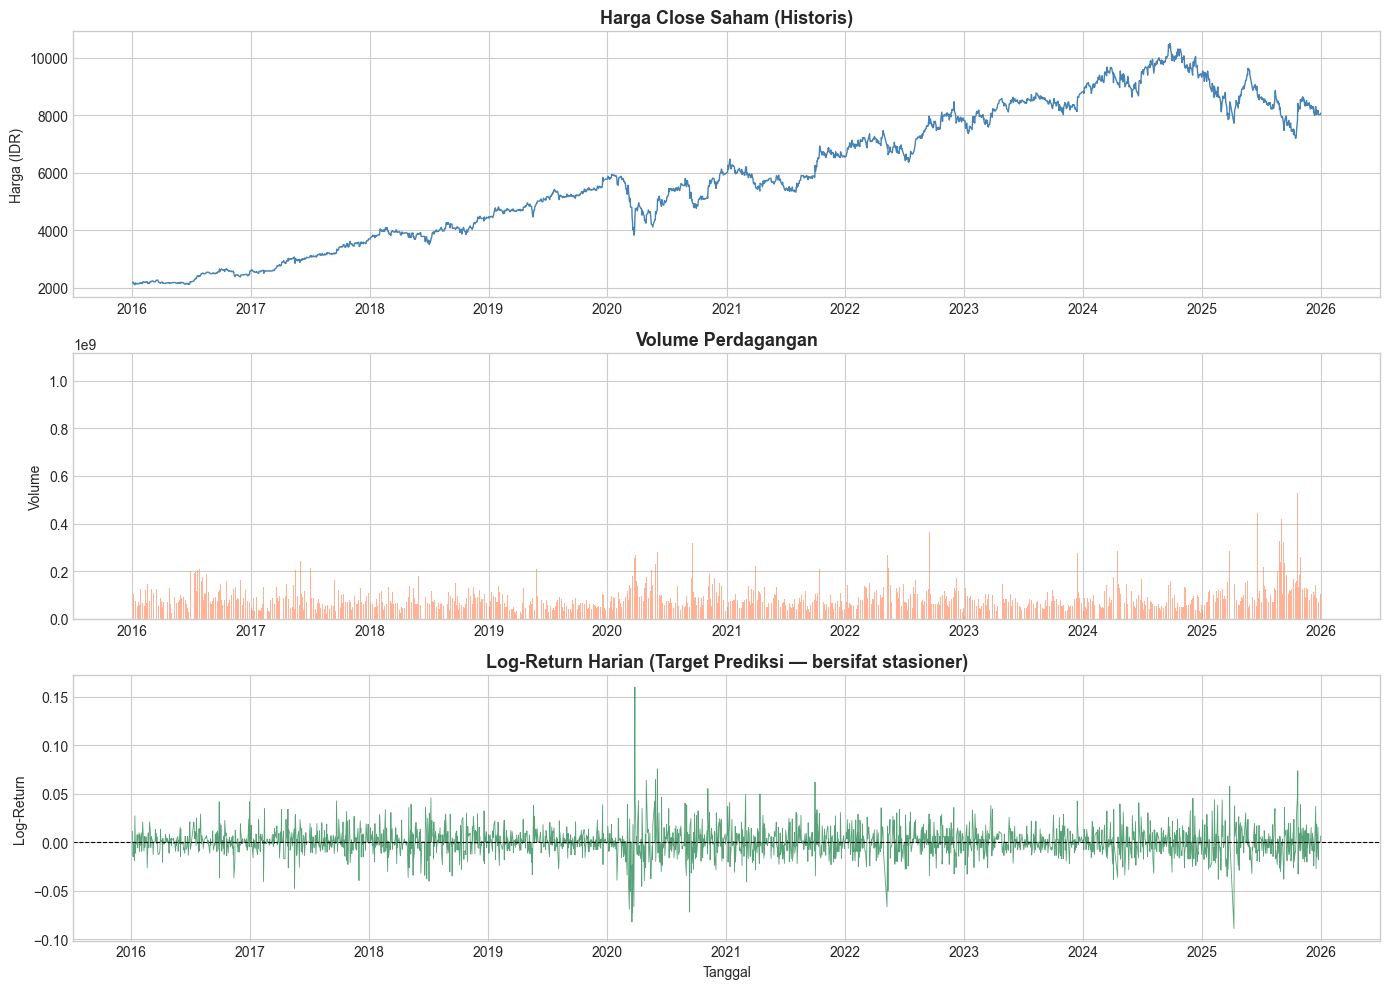

✅ Grafik EDA disimpan.


In [7]:
# ============================================================
# Visualisasi harga Close historis & volume
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(df.index, df['Close'], color='steelblue', linewidth=1)
axes[0].set_title('Harga Close Saham (Historis)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Harga (IDR)')

axes[1].bar(df.index, df['Volume'], color='coral', alpha=0.6, width=1)
axes[1].set_title('Volume Perdagangan', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Volume')

# Log-return harian untuk melihat stasioneritas
log_ret = np.log(df['Close'] / df['Close'].shift(1)).dropna()
axes[2].plot(log_ret.index, log_ret, color='seagreen', linewidth=0.6, alpha=0.8)
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title('Log-Return Harian (Target Prediksi — bersifat stasioner)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Log-Return')
axes[2].set_xlabel('Tanggal')

plt.tight_layout()
plt.savefig('eda_close_logret.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik EDA disimpan.')

In [8]:
# ============================================================
# Tangani missing value dengan forward fill
# ============================================================
before = df.isnull().sum().sum()
df = df.ffill().bfill()
after  = df.isnull().sum().sum()
print(f'Missing value sebelum : {before}')
print(f'Missing value sesudah : {after}')
print('✅ Penanganan missing value selesai.')

Missing value sebelum : 0
Missing value sesudah : 0
✅ Penanganan missing value selesai.


In [9]:
# ============================================================
# Konfigurasi global
# ============================================================
FEATURE_COLS      = ['Open', 'High', 'Low', 'Close', 'Volume']
LOOKBACK_CANDIDATES = [3]

print(f'Fitur dasar       : {FEATURE_COLS}')
print(f'Kandidat lookback : {LOOKBACK_CANDIDATES}')
print('Target prediksi   : log-return Close hari berikutnya')

Fitur dasar       : ['Open', 'High', 'Low', 'Close', 'Volume']
Kandidat lookback : [3]
Target prediksi   : log-return Close hari berikutnya


In [10]:
# ============================================================
# Fungsi: Buat lag features berbasis log-return
#
# Transformasi:
#   - Kolom harga (O/H/L/C) → log-return: ln(P_t / P_{t-1})
#   - Volume                 → log1p(Volume) untuk mengurangi skewness
#
# Target:
#   log_return[t+1] = ln(Close[t+1] / Close[t])  → shift(-1)
#
# Rekonstruksi harga prediksi:
#   Close_pred[t+1] = Close[t] * exp(log_return_pred)
#
# PENTING: Close[t] (untuk rekonstruksi) BUKAN fitur, sehingga
# tidak terjadi data leakage.
# ============================================================
def create_lag_features(df, feature_cols, lookback):
    """
    Membuat lag features log-return untuk XGBoost.

    Returns
    -------
    X           : array fitur  (n_samples, n_features)
    y_logret    : array target log-return  (n_samples,)
    close_t     : array Close[t] untuk rekonstruksi harga  (n_samples,)
    feature_names : list nama fitur
    """
    data = df[feature_cols].copy()

    # Transformasi ke log-return / log-scale
    price_cols = ['Open', 'High', 'Low', 'Close']
    transformed = {}
    for col in price_cols:
        transformed[f'{col}_logret'] = np.log(data[col] / data[col].shift(1))
    transformed['Volume_log'] = np.log1p(data['Volume'])
    transformed_df = pd.DataFrame(transformed, index=data.index)

    feat_cols_t = list(transformed_df.columns)

    # Buat lag features
    lag_frames = []
    col_names  = []
    for lag in range(1, lookback + 1):
        shifted = transformed_df.shift(lag)
        shifted.columns = [f'{c}_lag{lag}' for c in feat_cols_t]
        lag_frames.append(shifted)
        col_names.extend(shifted.columns.tolist())

    lag_df = pd.concat(lag_frames, axis=1)

    # Target: log-return Close hari berikutnya
    lag_df['target_logret'] = np.log(df['Close'] / df['Close'].shift(1)).shift(-1)

    # Simpan Close[t] untuk rekonstruksi (bukan fitur model)
    lag_df['Close_t'] = df['Close']

    # Hapus NaN
    lag_df = lag_df.dropna()

    X           = lag_df[col_names].values
    y_logret    = lag_df['target_logret'].values
    close_t     = lag_df['Close_t'].values
    feature_names = col_names

    return X, y_logret, close_t, feature_names


# ============================================================
# Fungsi: Split train/test kronologis (tanpa shuffle)
# ============================================================
def timeseries_split(X, y, close_t, test_ratio=0.20):
    n = len(X)
    split = int(n * (1 - test_ratio))
    return (X[:split], X[split:],
            y[:split], y[split:],
            close_t[:split], close_t[split:])


# ============================================================
# Fungsi: Hitung metrik evaluasi pada skala harga asli
# ============================================================
def compute_metrics(y_logret_true, y_logret_pred, close_t):
    """
    Konversi prediksi log-return → harga absolut, lalu hitung metrik.
    close_t : array Close[t] (harga hari ini, bukan hari berikutnya)
    """
    y_true_price = close_t * np.exp(y_logret_true)
    y_pred_price = close_t * np.exp(y_logret_pred)
    rmse = np.sqrt(mean_squared_error(y_true_price, y_pred_price))
    mae  = mean_absolute_error(y_true_price, y_pred_price)
    r2   = r2_score(y_true_price, y_pred_price)
    return rmse, mae, r2, y_true_price, y_pred_price


print('✅ Fungsi helper berhasil didefinisikan.')

✅ Fungsi helper berhasil didefinisikan.


In [11]:
# ============================================================
# Evaluasi setiap lookback menggunakan XGBoost default
# Pilih lookback dengan RMSE test terkecil
# MinMaxScaler di-fit HANYA pada data training
# ============================================================
print('=' * 58)
print(f'{"Lookback":>10} | {"RMSE":>10} | {"MAE":>10} | {"R²":>8} | {"n_test":>7}')
print('-' * 58)

lookback_results = []

for lb in LOOKBACK_CANDIDATES:
    X_all, y_all, c_all, feat_names = create_lag_features(df, FEATURE_COLS, lb)
    X_tr, X_te, y_tr, y_te, c_tr, c_te = timeseries_split(X_all, y_all, c_all)

    # Scaling pada fitur (X) — fit HANYA pada training
    # y (log-return) tidak perlu di-scale karena sudah near-zero mean
    scaler = MinMaxScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_te)

    model = XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_SEED, verbosity=0
    )
    model.fit(X_tr_sc, y_tr, verbose=False)

    y_pred = model.predict(X_te_sc)
    rmse, mae, r2, _, _ = compute_metrics(y_te, y_pred, c_te)

    lookback_results.append({
        'lookback': lb, 'rmse': rmse, 'mae': mae, 'r2': r2,
        'n_train': len(X_tr), 'n_test': len(X_te),
        'feat_names': feat_names
    })
    print(f'{lb:>10} | {rmse:>10.2f} | {mae:>10.2f} | {r2:>8.4f} | {len(X_te):>7}')

print('=' * 58)

best_lb_row   = min(lookback_results, key=lambda x: x['rmse'])
BEST_LOOKBACK = best_lb_row['lookback']
print(f'\n✅ Lookback terbaik : {BEST_LOOKBACK} (RMSE = {best_lb_row["rmse"]:.4f}, R² = {best_lb_row["r2"]:.4f})')

  Lookback |       RMSE |        MAE |       R² |  n_test
----------------------------------------------------------
         3 |     146.97 |     111.50 |   0.9569 |     493

✅ Lookback terbaik : 3 (RMSE = 146.9727, R² = 0.9569)


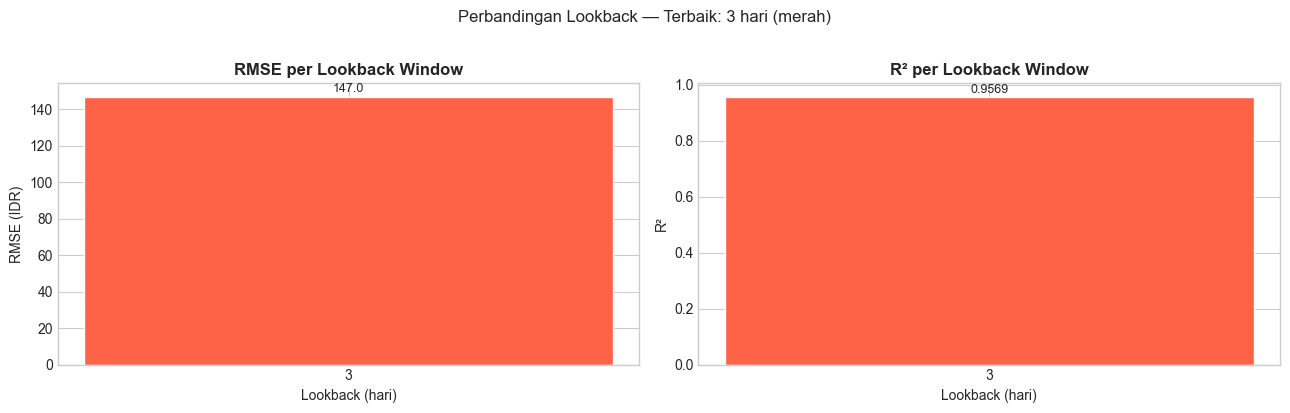

In [12]:
# ============================================================
# Visualisasi perbandingan RMSE & R² per lookback
# ============================================================
lb_vals   = [r['lookback'] for r in lookback_results]
rmse_vals = [r['rmse']     for r in lookback_results]
r2_vals   = [r['r2']       for r in lookback_results]
colors    = ['tomato' if lb == BEST_LOOKBACK else 'steelblue' for lb in lb_vals]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bars = axes[0].bar([str(lb) for lb in lb_vals], rmse_vals, color=colors, edgecolor='white')
for bar, val in zip(bars, rmse_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(rmse_vals)*0.005,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=9)
axes[0].set_title('RMSE per Lookback Window', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lookback (hari)')
axes[0].set_ylabel('RMSE (IDR)')

bars2 = axes[1].bar([str(lb) for lb in lb_vals], r2_vals, color=colors, edgecolor='white')
for bar, val in zip(bars2, r2_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)
axes[1].set_title('R² per Lookback Window', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lookback (hari)')
axes[1].set_ylabel('R²')

plt.suptitle(f'Perbandingan Lookback — Terbaik: {BEST_LOOKBACK} hari (merah)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('lookback_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ============================================================
# Buat dataset final dengan lookback terbaik
# ============================================================
X_all, y_all, c_all, FEATURE_NAMES = create_lag_features(df, FEATURE_COLS, BEST_LOOKBACK)
X_train, X_test, y_train, y_test, c_train, c_test = timeseries_split(X_all, y_all, c_all)

# MinMaxScaler di-fit HANYA pada training set
scaler_X = MinMaxScaler()
X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)

# y (log-return) tidak perlu di-scale
print(f'Lookback terbaik  : {BEST_LOOKBACK} hari')
print(f'Jumlah fitur      : {X_train.shape[1]}')
print(f'Ukuran training   : {X_train.shape[0]:,} sampel ({X_train.shape[0]/(X_train.shape[0]+X_test.shape[0])*100:.1f}%)')
print(f'Ukuran testing    : {X_test.shape[0]:,} sampel ({X_test.shape[0]/(X_train.shape[0]+X_test.shape[0])*100:.1f}%)')
print(f'y_train range     : {y_train.min():.5f} s.d. {y_train.max():.5f}')
print(f'y_test  range     : {y_test.min():.5f} s.d. {y_test.max():.5f}')
print('✅ Tidak ada out-of-range issue (log-return stasioner).')

Lookback terbaik  : 3 hari
Jumlah fitur      : 15
Ukuran training   : 1,968 sampel (80.0%)
Ukuran testing    : 493 sampel (20.0%)
y_train range     : -0.08244 s.d. 0.15985
y_test  range     : -0.08915 s.d. 0.07343
✅ Tidak ada out-of-range issue (log-return stasioner).


In [14]:
# ============================================================
# Objective function untuk Optuna
# Metrik: RMSE pada skala harga asli (IDR)
# ============================================================
def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators',      100, 1000, step=50),
        'max_depth'        : trial.suggest_int('max_depth',           3,    9),
        'learning_rate'    : trial.suggest_float('learning_rate',  0.005, 0.3,  log=True),
        'subsample'        : trial.suggest_float('subsample',        0.5,  1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5,  1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight',    1,   10),
        'reg_alpha'        : trial.suggest_float('reg_alpha',        0.0,  1.0),
        'reg_lambda'       : trial.suggest_float('reg_lambda',       0.5,  5.0),
        'random_state'     : RANDOM_SEED,
        'verbosity'        : 0,
        'tree_method'      : 'hist',
    }
    model = XGBRegressor(**params)
    model.fit(X_train_sc, y_train, eval_set=[(X_test_sc, y_test)], verbose=False)

    y_pred = model.predict(X_test_sc)
    rmse, _, _, _, _ = compute_metrics(y_test, y_pred, c_test)
    return rmse


# ============================================================
# Jalankan Optuna — minimal 50 trial
# ============================================================
N_TRIALS = 50

print(f'Memulai Optuna hyperparameter search ({N_TRIALS} trial)...')
study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=RANDOM_SEED),
    study_name='xgboost_stock_logret'
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\n✅ Optuna selesai.')
print(f'   RMSE terbaik (IDR) : {study.best_value:.4f}')
print('   Parameter terbaik :')
for k, v in study.best_params.items():
    print(f'     {k:<22}: {v}')

Memulai Optuna hyperparameter search (50 trial)...


Best trial: 4. Best value: 140.936: 100%|██████████| 50/50 [00:53<00:00,  1.07s/it]


✅ Optuna selesai.
   RMSE terbaik (IDR) : 140.9359
   Parameter terbaik :
     n_estimators          : 150
     max_depth             : 9
     learning_rate         : 0.260621242754743
     subsample             : 0.9041986740582306
     colsample_bytree      : 0.6523068845866853
     min_child_weight      : 1
     reg_alpha             : 0.6842330265121569
     reg_lambda            : 2.480686221828206


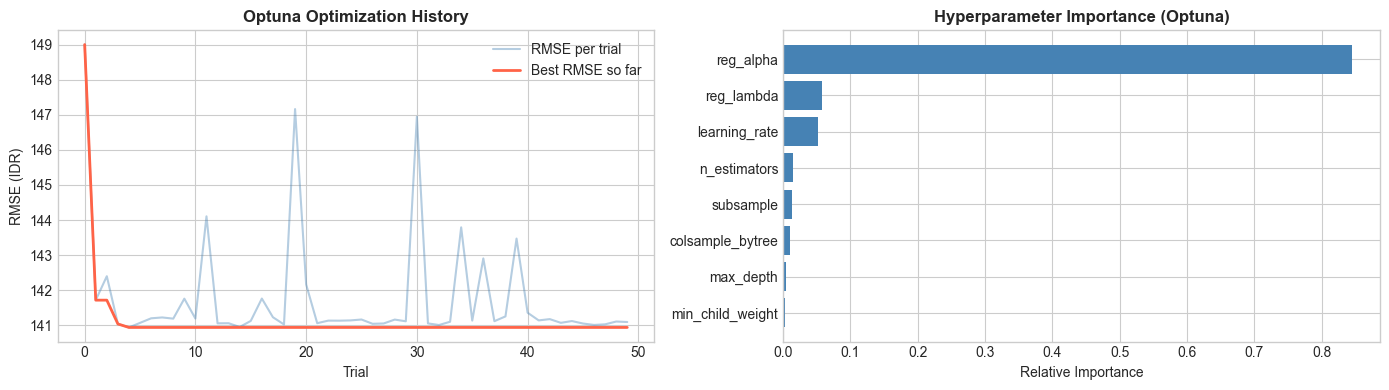

In [15]:
# ============================================================
# Visualisasi Optuna
# ============================================================
trial_vals  = [t.value for t in study.trials]
best_so_far = [min(trial_vals[:i+1]) for i in range(len(trial_vals))]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(trial_vals, alpha=0.4, color='steelblue', label='RMSE per trial')
axes[0].plot(best_so_far, color='tomato', linewidth=2, label='Best RMSE so far')
axes[0].set_title('Optuna Optimization History', fontweight='bold')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('RMSE (IDR)')
axes[0].legend()

importances = optuna.importance.get_param_importances(study)
imp_keys = list(importances.keys())
imp_vals = list(importances.values())
axes[1].barh(imp_keys[::-1], imp_vals[::-1], color='steelblue')
axes[1].set_title('Hyperparameter Importance (Optuna)', fontweight='bold')
axes[1].set_xlabel('Relative Importance')

plt.tight_layout()
plt.savefig('optuna_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ============================================================
# Latih model final menggunakan hyperparameter terbaik Optuna
# ============================================================
best_params = study.best_params.copy()
best_params.update({'random_state': RANDOM_SEED, 'verbosity': 0, 'tree_method': 'hist'})

best_model = XGBRegressor(**best_params)
best_model.fit(
    X_train_sc, y_train,
    eval_set=[(X_train_sc, y_train), (X_test_sc, y_test)],
    verbose=False
)

print('✅ Model XGBoost terbaik selesai dilatih.')

✅ Model XGBoost terbaik selesai dilatih.


In [17]:
# ============================================================
# Prediksi dan evaluasi pada skala harga asli (IDR)
# Alur: prediksi log-return → rekonstruksi harga absolut → hitung metrik
# ============================================================
y_train_pred_lr = best_model.predict(X_train_sc)
y_test_pred_lr  = best_model.predict(X_test_sc)

train_rmse, train_mae, train_r2, y_train_true_p, y_train_pred_p = \
    compute_metrics(y_train, y_train_pred_lr, c_train)
test_rmse,  test_mae,  test_r2,  y_test_true_p,  y_test_pred_p  = \
    compute_metrics(y_test,  y_test_pred_lr,  c_test)

print('=== Evaluasi Model XGBoost (skala harga asli) ===')
print(f'  [Training] RMSE: {train_rmse:.4f}  |  MAE: {train_mae:.4f}  |  R²: {train_r2:.4f}')
print(f'  [Testing ] RMSE: {test_rmse:.4f}  |  MAE: {test_mae:.4f}  |  R²: {test_r2:.4f}')
print(f'\n  Rasio RMSE Test/Train : {test_rmse/train_rmse:.3f}  (mendekati 1 = tidak overfit)')

# Tabel ringkas
eval_df = pd.DataFrame({
    'Metrik'   : ['RMSE (IDR)', 'MAE (IDR)', 'R²'],
    'Training' : [train_rmse, train_mae, train_r2],
    'Testing'  : [test_rmse,  test_mae,  test_r2]
})
display(eval_df.set_index('Metrik'))

=== Evaluasi Model XGBoost (skala harga asli) ===
  [Training] RMSE: 74.0936  |  MAE: 48.6108  |  R²: 0.9985
  [Testing ] RMSE: 140.9359  |  MAE: 106.0307  |  R²: 0.9604

  Rasio RMSE Test/Train : 1.902  (mendekati 1 = tidak overfit)


,Training,Testing
Metrik,,
RMSE (IDR),74.0936,140.9359
MAE (IDR),48.6108,106.0307
R²,0.9985,0.9604


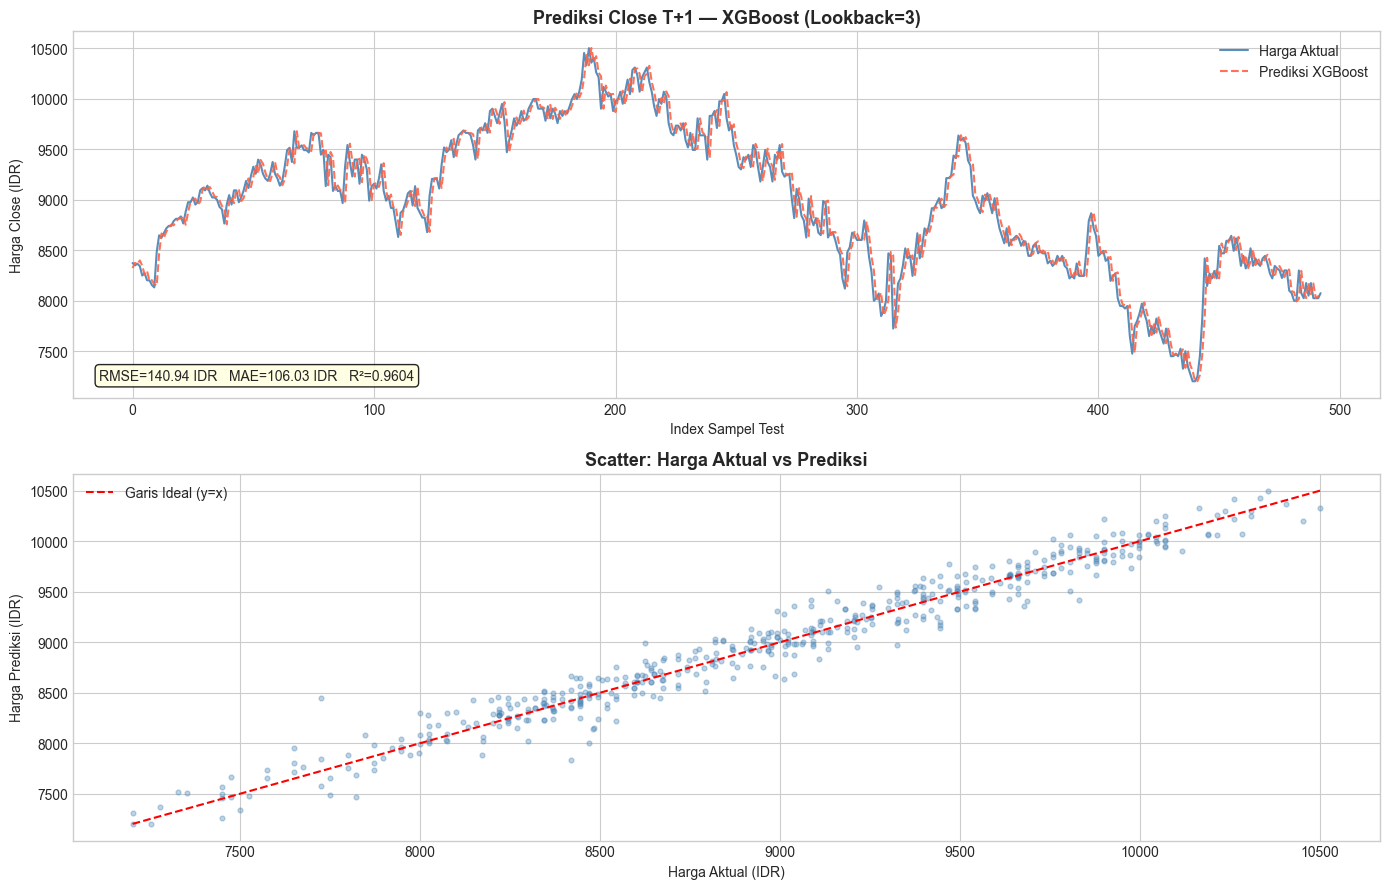

In [18]:
# ============================================================
# Visualisasi Actual vs Predicted pada data testing
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# ── Plot 1: Time series ──
idx = range(len(y_test_true_p))
axes[0].plot(idx, y_test_true_p,  color='steelblue', linewidth=1.5, label='Harga Aktual', alpha=0.9)
axes[0].plot(idx, y_test_pred_p,  color='tomato',    linewidth=1.5, linestyle='--',
             label='Prediksi XGBoost', alpha=0.9)
axes[0].set_title(f'Prediksi Close T+1 — XGBoost (Lookback={BEST_LOOKBACK})',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Index Sampel Test')
axes[0].set_ylabel('Harga Close (IDR)')
axes[0].legend()
axes[0].text(0.02, 0.05,
    f'RMSE={test_rmse:.2f} IDR   MAE={test_mae:.2f} IDR   R²={test_r2:.4f}',
    transform=axes[0].transAxes, fontsize=10,
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))

# ── Plot 2: Scatter Actual vs Predicted ──
axes[1].scatter(y_test_true_p, y_test_pred_p, alpha=0.35, s=12, color='steelblue')
lo = min(y_test_true_p.min(), y_test_pred_p.min())
hi = max(y_test_true_p.max(), y_test_pred_p.max())
axes[1].plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Garis Ideal (y=x)')
axes[1].set_title('Scatter: Harga Aktual vs Prediksi', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Harga Aktual (IDR)')
axes[1].set_ylabel('Harga Prediksi (IDR)')
axes[1].legend()

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

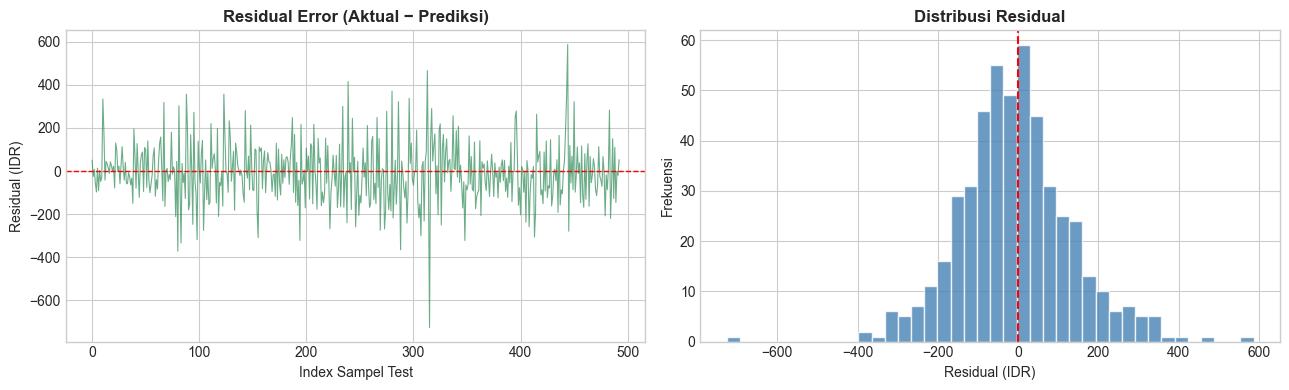

In [19]:
# ============================================================
# Visualisasi residual (error prediksi)
# ============================================================
residuals = y_test_true_p - y_test_pred_p

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(residuals, color='seagreen', linewidth=0.8, alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Residual Error (Aktual − Prediksi)', fontweight='bold')
axes[0].set_xlabel('Index Sampel Test')
axes[0].set_ylabel('Residual (IDR)')

axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Distribusi Residual', fontweight='bold')
axes[1].set_xlabel('Residual (IDR)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

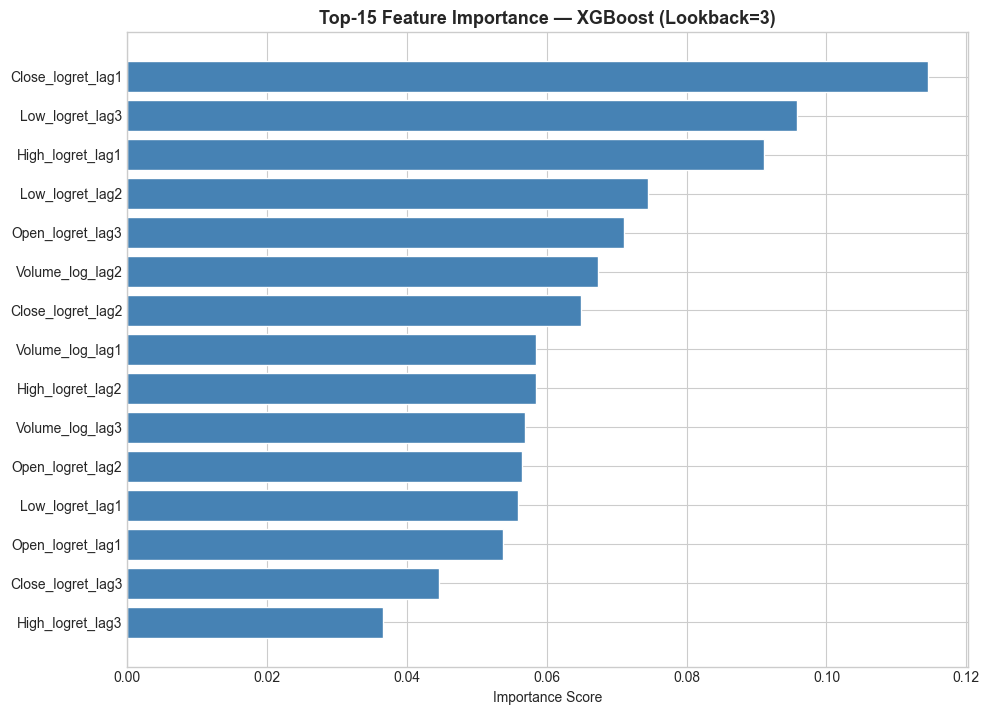

Top-5 fitur terpenting:
          Feature  Importance
Close_logret_lag1      0.1145
  Low_logret_lag3      0.0957
 High_logret_lag1      0.0911
  Low_logret_lag2      0.0744
 Open_logret_lag3      0.0710


In [20]:
# ============================================================
# Feature Importance — lag mana yang paling berpengaruh
# ============================================================
importances = best_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature'   : FEATURE_NAMES,
    'Importance': importances
}).sort_values('Importance', ascending=False)

top_n     = min(20, len(feat_imp_df))
top_feats = feat_imp_df.head(top_n)

plt.figure(figsize=(10, top_n * 0.35 + 2))
plt.barh(top_feats['Feature'].values[::-1],
         top_feats['Importance'].values[::-1],
         color='steelblue', edgecolor='white')
plt.title(f'Top-{top_n} Feature Importance — XGBoost (Lookback={BEST_LOOKBACK})',
           fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top-5 fitur terpenting:')
print(feat_imp_df.head(5).to_string(index=False))

In [21]:
# ============================================================
# Walk-Forward Validation (expanding window, 5-fold)
#
# Strategi expanding window:
#   Fold 1: train = [0..fold_size-1],         val = [fold_size..2*fold_size-1]
#   Fold 2: train = [0..2*fold_size-1],        val = [2*fold_size..3*fold_size-1]
#   ...dst.
#
# MinMaxScaler di-fit ulang di setiap fold (hanya pada training fold)
# ============================================================
N_FOLDS = 5
X_wfv, y_wfv, c_wfv, _ = create_lag_features(df, FEATURE_COLS, BEST_LOOKBACK)

fold_size   = len(X_wfv) // (N_FOLDS + 1)
wfv_results = []

print(f'Walk-Forward Validation — {N_FOLDS} fold (Expanding Window)')
print(f'Total data  : {len(X_wfv):,} sampel | Fold size: ±{fold_size:,} sampel')
print('=' * 70)
print(f'{"Fold":>6} | {"n_train":>8} | {"n_val":>8} | {"RMSE (IDR)":>12} | {"MAE (IDR)":>12} | {"R²":>8}')
print('-' * 70)

for fold in range(1, N_FOLDS + 1):
    train_end = fold * fold_size
    val_end   = min(train_end + fold_size, len(X_wfv))

    X_tr_f = X_wfv[:train_end]
    y_tr_f = y_wfv[:train_end]
    c_tr_f = c_wfv[:train_end]
    X_vl_f = X_wfv[train_end:val_end]
    y_vl_f = y_wfv[train_end:val_end]
    c_vl_f = c_wfv[train_end:val_end]

    if len(X_vl_f) == 0:
        continue

    # Scaling ulang — fit HANYA pada training fold
    sc_f = MinMaxScaler()
    X_tr_f_sc = sc_f.fit_transform(X_tr_f)
    X_vl_f_sc = sc_f.transform(X_vl_f)

    model_f = XGBRegressor(**best_params)
    model_f.fit(X_tr_f_sc, y_tr_f, verbose=False)

    y_pred_f = model_f.predict(X_vl_f_sc)
    rmse_f, mae_f, r2_f, _, _ = compute_metrics(y_vl_f, y_pred_f, c_vl_f)

    wfv_results.append({'fold': fold, 'rmse': rmse_f, 'mae': mae_f, 'r2': r2_f,
                        'n_train': len(X_tr_f), 'n_val': len(X_vl_f)})
    print(f'{fold:>6} | {len(X_tr_f):>8,} | {len(X_vl_f):>8,} | {rmse_f:>12.4f} | {mae_f:>12.4f} | {r2_f:>8.4f}')

print('=' * 70)
avg_rmse = np.mean([r['rmse'] for r in wfv_results])
avg_mae  = np.mean([r['mae']  for r in wfv_results])
avg_r2   = np.mean([r['r2']   for r in wfv_results])
std_rmse = np.std([r['rmse']  for r in wfv_results])
print(f'{"Rata-rata":>6} | {"":>8} | {"":>8} | {avg_rmse:>12.4f} | {avg_mae:>12.4f} | {avg_r2:>8.4f}')
print(f'{"Std Dev":>6} | {"":>8} | {"":>8} | {std_rmse:>12.4f} |')
print(f'\n✅ Walk-forward validation selesai.')

Walk-Forward Validation — 5 fold (Expanding Window)
Total data  : 2,461 sampel | Fold size: ±410 sampel
  Fold |  n_train |    n_val |   RMSE (IDR) |    MAE (IDR) |       R²
----------------------------------------------------------------------
     1 |      410 |      410 |      50.3214 |      35.3855 |   0.9841
     2 |      820 |      410 |      91.9741 |      58.4529 |   0.9473
     3 |    1,230 |      410 |      94.3445 |      69.4480 |   0.9730
     4 |    1,640 |      410 |      97.5353 |      72.9329 |   0.9699
     5 |    2,050 |      410 |     146.8960 |     111.9640 |   0.9621
Rata-rata |          |          |      96.2142 |      69.6367 |   0.9673
Std Dev |          |          |      30.6529 |

✅ Walk-forward validation selesai.


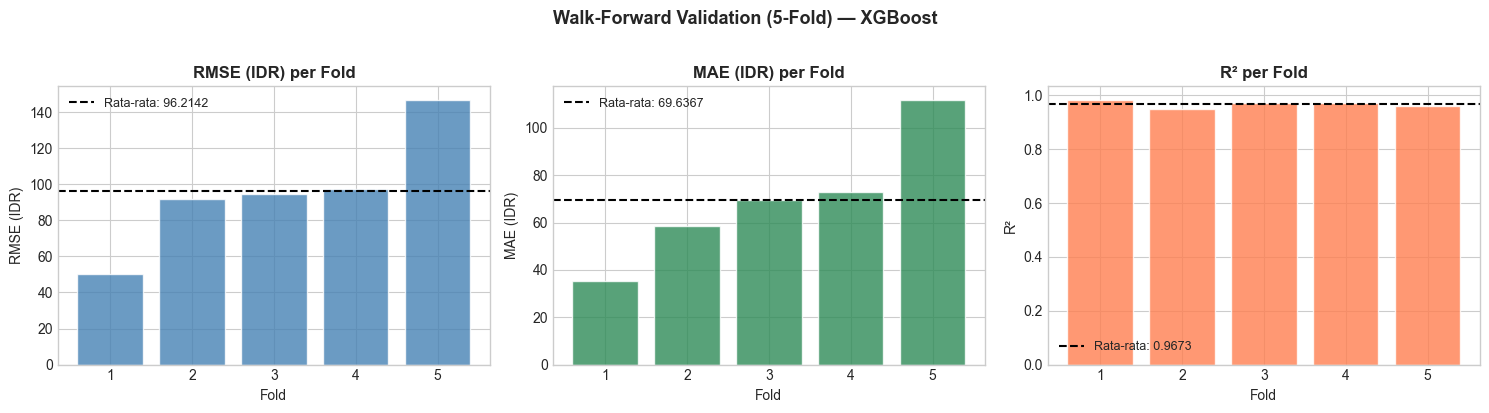

In [22]:
# ============================================================
# Visualisasi walk-forward validation
# ============================================================
folds_list = [r['fold'] for r in wfv_results]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, label, color in zip(
    axes, ['rmse', 'mae', 'r2'], ['RMSE (IDR)', 'MAE (IDR)', 'R²'],
    ['steelblue', 'seagreen', 'coral']
):
    vals = [r[metric] for r in wfv_results]
    avg  = np.mean(vals)
    ax.bar(folds_list, vals, color=color, alpha=0.8, edgecolor='white')
    ax.axhline(avg, color='black', linestyle='--', linewidth=1.5,
               label=f'Rata-rata: {avg:.4f}')
    ax.set_title(f'{label} per Fold', fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_ylabel(label)
    ax.legend(fontsize=9)
    ax.set_xticks(folds_list)

plt.suptitle('Walk-Forward Validation (5-Fold) — XGBoost', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('walk_forward_validation.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ============================================================
# Cetak ringkasan lengkap untuk skripsi
# ============================================================
sep = '═' * 60
print(sep)
print('  RINGKASAN HASIL — XGBoost Stock Price Prediction')
print(sep)
print(f'  Dataset              : {filename}')
print(f'  Target               : Close T+1 (via log-return)')
print(f'  Lookback terbaik     : {BEST_LOOKBACK} hari')
print(f'  Jumlah fitur         : {X_train.shape[1]}')
print()
print('  Hyperparameter Terbaik (Optuna):')
for k, v in study.best_params.items():
    tag = f'{k:<24}'
    print(f'    {tag}: {v:.6f}' if isinstance(v, float) else f'    {tag}: {v}')
print()
print('  Evaluasi Data Test (skala harga asli, IDR):')
print(f'    RMSE  : {test_rmse:.4f}')
print(f'    MAE   : {test_mae:.4f}')
print(f'    R²    : {test_r2:.4f}')
print()
print(f'  Walk-Forward Validation (5-fold, rata-rata):')
print(f'    RMSE  : {avg_rmse:.4f}  (±{std_rmse:.4f})')
print(f'    MAE   : {avg_mae:.4f}')
print(f'    R²    : {avg_r2:.4f}')
print(sep)

════════════════════════════════════════════════════════════
  RINGKASAN HASIL — XGBoost Stock Price Prediction
════════════════════════════════════════════════════════════
  Dataset              : bbca_data.csv
  Target               : Close T+1 (via log-return)
  Lookback terbaik     : 3 hari
  Jumlah fitur         : 15

  Hyperparameter Terbaik (Optuna):
    n_estimators            : 150
    max_depth               : 9
    learning_rate           : 0.260621
    subsample               : 0.904199
    colsample_bytree        : 0.652307
    min_child_weight        : 1
    reg_alpha               : 0.684233
    reg_lambda              : 2.480686

  Evaluasi Data Test (skala harga asli, IDR):
    RMSE  : 140.9359
    MAE   : 106.0307
    R²    : 0.9604

  Walk-Forward Validation (5-fold, rata-rata):
    RMSE  : 96.2142  (±30.6529)
    MAE   : 69.6367
    R²    : 0.9673
════════════════════════════════════════════════════════════


In [24]:
# ============================================================
# Simpan model XGBoost ke file .json
# ============================================================
MODEL_PATH   = f'xgboost_best_lb{BEST_LOOKBACK}.json'
SUMMARY_PATH = f'xgboost_summary_lb{BEST_LOOKBACK}.json'

# Simpan bobot model
best_model.save_model(MODEL_PATH)
print(f'✅ Model disimpan : {MODEL_PATH}')

# Simpan ringkasan metrik & hyperparameter
summary = {
    'best_lookback'       : int(BEST_LOOKBACK),
    'target_type'         : 'log_return',
    'feature_names'       : FEATURE_NAMES,
    'best_hyperparams'    : {k: (float(v) if isinstance(v, float) else int(v) if isinstance(v, int) else v)
                             for k, v in study.best_params.items()},
    'test_metrics'        : {
        'rmse': float(test_rmse), 'mae': float(test_mae), 'r2': float(test_r2)
    },
    'wfv_avg_metrics'     : {
        'rmse': float(avg_rmse), 'mae': float(avg_mae), 'r2': float(avg_r2),
        'rmse_std': float(std_rmse)
    },
    'wfv_fold_details'    : wfv_results
}
with open(SUMMARY_PATH, 'w') as f:
    json.dump(summary, f, indent=2)
print(f'✅ Ringkasan disimpan : {SUMMARY_PATH}')

# Download ke komputer lokal
#files.download(MODEL_PATH)
#files.download(SUMMARY_PATH)

print(f"\n📁 Model tersimpan di:")
print(MODEL_PATH)

print(f"\n📁 Ringkasan tersimpan di:")
print(SUMMARY_PATH)

✅ Model disimpan : xgboost_best_lb3.json
✅ Ringkasan disimpan : xgboost_summary_lb3.json

📁 Model tersimpan di:
xgboost_best_lb3.json

📁 Ringkasan tersimpan di:
xgboost_summary_lb3.json


In [25]:
# ============================================================
# Verifikasi: Load model tersimpan & uji konsistensi prediksi
# ============================================================
model_verify = XGBRegressor()
model_verify.load_model(MODEL_PATH)

y_verify_lr = model_verify.predict(X_test_sc)
rmse_v, _, r2_v, _, _ = compute_metrics(y_test, y_verify_lr, c_test)

print('Verifikasi model tersimpan:')
print(f'  RMSE (setelah load) : {rmse_v:.4f}')
print(f'  RMSE (sebelumnya)   : {test_rmse:.4f}')
diff = abs(rmse_v - test_rmse)
print(f'  Status : {"✅ Konsisten" if diff < 1e-3 else "⚠️ Cek ulang"}  (selisih={diff:.6f})')

Verifikasi model tersimpan:
  RMSE (setelah load) : 140.9359
  RMSE (sebelumnya)   : 140.9359
  Status : ✅ Konsisten  (selisih=0.000000)


In [26]:
# ============================================================
# SAVE BEST MODEL
# ============================================================

best_model.save_model("xgboost_best_model.json")

print("✅ Model tersimpan: xgboost_best_model.json")

✅ Model tersimpan: xgboost_best_model.json


In [27]:
import joblib

scaler = joblib.load("preprocessor.pkl")

print("Jumlah fitur yang diharapkan scaler:")
print(scaler.n_features_in_)

Jumlah fitur yang diharapkan scaler:
150


In [28]:
import joblib

joblib.dump(scaler, "preprocessor.pkl")

print("✅ Preprocessor tersimpan: preprocessor.pkl")

✅ Preprocessor tersimpan: preprocessor.pkl


In [29]:
import json

model_config = {
    "lookback": BEST_LOOKBACK,
    "features": ["Open", "High", "Low", "Close", "Volume"],
    "target": "Close",
    "scaler_type": "MinMaxScaler"
}

with open("model_config.json", "w") as f:
    json.dump(model_config, f, indent=4)

print("✅ Config tersimpan: model_config.json")

✅ Config tersimpan: model_config.json


In [30]:
results = {
    "RMSE": float(test_rmse),
    "MAE": float(test_mae),
    "R2": float(test_r2),
    "Best_Lookback": int(BEST_LOOKBACK)
}

with open("results.json", "w") as f:
    json.dump(results, f, indent=4)

print("✅ Hasil evaluasi tersimpan: results.json")

✅ Hasil evaluasi tersimpan: results.json


In [31]:
print("BEST_LOOKBACK =", BEST_LOOKBACK)
print(len(FEATURE_NAMES))
print(FEATURE_NAMES[:10])

BEST_LOOKBACK = 3
15
['Open_logret_lag1', 'High_logret_lag1', 'Low_logret_lag1', 'Close_logret_lag1', 'Volume_log_lag1', 'Open_logret_lag2', 'High_logret_lag2', 'Low_logret_lag2', 'Close_logret_lag2', 'Volume_log_lag2']


In [32]:
import joblib

scaler = joblib.load("preprocessor.pkl")
print(scaler.n_features_in_)

150


In [33]:
print("Scaler expects:", scaler.n_features_in_)

Scaler expects: 150
